In [1]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU available: True
GPU name: Tesla T4
GPU memory: 15.6 GB


In [22]:
!curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"
!unzip -q awscliv2.zip
!sudo ./aws/install --update
!aws --version


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 66.6M  100 66.6M    0     0   164M      0 --:--:-- --:--:-- --:--:--  165M
You can now run: /usr/local/bin/aws --version
aws-cli/2.34.37 Python/3.14.4 Linux/6.6.113+ exe/x86_64.ubuntu.22


In [2]:
!pip install boto3 pandas pyarrow fastparquet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.3 MB/s eta 0:00:00


In [ ]:
import subprocess
subprocess.run(['aws', 'configure', 'set', 'aws_access_key_id', ''])
subprocess.run(['aws', 'configure', 'set', 'aws_secret_access_key', ''])
subprocess.run(['aws', 'configure', 'set', 'default.region', 'us-east-1'])


CompletedProcess(args=['aws', 'configure', 'set', 'default.region', 'us-east-1'], returncode=0)

In [26]:
!aws s3 ls s3://25tvtm-cisc886-bucket-cloud-project/processed/train/ | head -3


2026-04-27 07:53:46          0 _SUCCESS
2026-04-27 07:53:17   30219791 part-00000-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet
2026-04-27 07:53:16   30434028 part-00001-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet
Traceback (most recent call last):
  File "awscli/clidriver.py", line 550, in main
  File "awscli/customizations/commands.py", line 153, in __call__
  File "awscli/customizations/commands.py", line 207, in __call__
  File "awscli/customizations/s3/subcommands.py", line 824, in _run_main
  File "awscli/customizations/s3/subcommands.py", line 857, in _list_all_objects
  File "awscli/customizations/s3/subcommands.py", line 882, in _display_page
  File "awscli/customizations/utils.py", line 205, in uni_print
BrokenPipeError: [Errno 32] Broken pipe

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "awscli/clidriver.py", line 196, in main
  File "awscli/clidriver.py", line 236, in _do_main
  File 

In [28]:
import boto3
import subprocess
import configparser
import os

# Read credentials that aws configure saved
creds = configparser.ConfigParser()
creds.read(os.path.expanduser('~/.aws/credentials'))

access_key = creds['default']['aws_access_key_id']
secret_key = creds['default']['aws_secret_access_key']

# Pass directly to boto3
s3 = boto3.client(
    's3',
    region_name          = 'us-east-1',
    aws_access_key_id     = access_key,
    aws_secret_access_key = secret_key
)

BUCKET = '25tvtm-cisc886-bucket-cloud-project'

try:
    s3.head_bucket(Bucket=BUCKET)
    print("✅ Connected successfully")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Connected successfully


In [29]:
response = s3.list_objects_v2(Bucket=BUCKET, Prefix='processed/train/')
files = [obj['Key'] for obj in response.get('Contents', []) if obj['Key'].endswith('.parquet')]
print(f"Found {len(files)} parquet files in train/")
for f in files[:5]:
    print(f" - {f}")

Found 100 parquet files in train/
 - processed/train/part-00000-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet
 - processed/train/part-00001-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet
 - processed/train/part-00002-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet
 - processed/train/part-00003-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet
 - processed/train/part-00004-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet


In [38]:
import pandas as pd
from io import BytesIO

# Load first parquet file as a sample
obj = s3.get_object(Bucket=BUCKET, Key=files[0])
df = pd.read_parquet(BytesIO(obj['Body'].read()))

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample row:")
print(df.iloc[0])

Shape: (136895, 5)

Columns: ['product_id', 'reviewer_id', 'rating', 'prompt', 'response']

Sample row:
product_id                                            0446581348
reviewer_id                         AFPDOOE52APJ6MLFLWGZ44AR7BVQ
rating                                                       5.0
prompt         A customer reviewed a beauty and personal care...
response                                              great book
Name: 0, dtype: object


In [41]:
splits = ['processed/train/', 'processed/val/', 'processed/test/']

for split in splits:
    response = s3.list_objects_v2(Bucket=BUCKET, Prefix=split)
    files = [
        obj['Key'] for obj in response.get('Contents', [])
        if obj['Key'].endswith('.parquet')
    ]
    total_size = sum(
        obj['Size'] for obj in response.get('Contents', [])
        if obj['Key'].endswith('.parquet')
    )
    print(f"{split}")
    print(f"  Files:      {len(files)} parquet files")
    print(f"  Total size: {total_size / 1e6:.1f} MB")
    print(f"  First file: {files[0] if files else 'none'}")
    print()

processed/train/
  Files:      100 parquet files
  Total size: 3029.3 MB
  First file: processed/train/part-00000-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet

processed/val/
  Files:      100 parquet files
  Total size: 390.7 MB
  First file: processed/val/part-00000-e6e0017e-da75-4bb3-84ac-b4851accfa3a-c000.snappy.parquet

processed/test/
  Files:      100 parquet files
  Total size: 391.2 MB
  First file: processed/test/part-00000-34d744b7-c48b-4cfa-bfbb-bea562c9159a-c000.snappy.parquet



In [42]:
import pandas as pd
from io import BytesIO

def load_parquet_sample(prefix, max_files=2):
    response = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix)
    files = [
        obj['Key'] for obj in response.get('Contents', [])
        if obj['Key'].endswith('.parquet')
    ][:max_files]

    dfs = []
    for key in files:
        obj = s3.get_object(Bucket=BUCKET, Key=key)
        df  = pd.read_parquet(BytesIO(obj['Body'].read()))
        dfs.append(df)
        print(f"  Loaded {key.split('/')[-1]} — {len(df):,} rows")

    return pd.concat(dfs, ignore_index=True)

print("Loading train sample...")
train_df = load_parquet_sample('processed/train/', max_files=3)

print("\nLoading val sample...")
val_df = load_parquet_sample('processed/val/', max_files=1)

print("\nLoading test sample...")
test_df = load_parquet_sample('processed/test/', max_files=1)

# Add split label
train_df['split'] = 'train'
val_df['split']   = 'val'
test_df['split']  = 'test'

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"\n{'='*40}")
print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")
print(f"Total: {len(df):,}")

Loading train sample...
  Loaded part-00000-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 136,895 rows
  Loaded part-00001-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 138,076 rows
  Loaded part-00002-e324d698-3f48-429b-a5fa-91b2fa994ff0-c000.snappy.parquet — 149,068 rows

Loading val sample...
  Loaded part-00000-e6e0017e-da75-4bb3-84ac-b4851accfa3a-c000.snappy.parquet — 16,575 rows

Loading test sample...
  Loaded part-00000-34d744b7-c48b-4cfa-bfbb-bea562c9159a-c000.snappy.parquet — 15,964 rows

Train: 424,039
Val:   16,575
Test:  15,964
Total: 456,578


In [43]:
print("Columns:", df.columns.tolist())
print(f"Shape:   {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nNull counts:")
print(df.isnull().sum())
print(f"\nSample row:")
print("-" * 60)
print(f"product_id:  {df['product_id'].iloc[0]}")
print(f"reviewer_id: {df['reviewer_id'].iloc[0]}")
print(f"rating:      {df['rating'].iloc[0]}")
print(f"\nprompt:\n{df['prompt'].iloc[0]}")
print(f"\nresponse:\n{df['response'].iloc[0]}")

Columns: ['product_id', 'reviewer_id', 'rating', 'prompt', 'response', 'split']
Shape:   (456578, 6)

Data types:
product_id      object
reviewer_id     object
rating         float64
prompt          object
response        object
split           object
dtype: object

Null counts:
product_id     0
reviewer_id    0
rating         0
prompt         0
response       0
split          0
dtype: int64

Sample row:
------------------------------------------------------------
product_id:  0446581348
reviewer_id: AFPDOOE52APJ6MLFLWGZ44AR7BVQ
rating:      5.0

prompt:
A customer reviewed a beauty and personal care product with ID 0446581348 and gave it 5.0 out of 5 stars. Review: Very useful and handy to have. You can learn a lot from this book. Came in good condition as posted. Summarize this review.

response:
great book


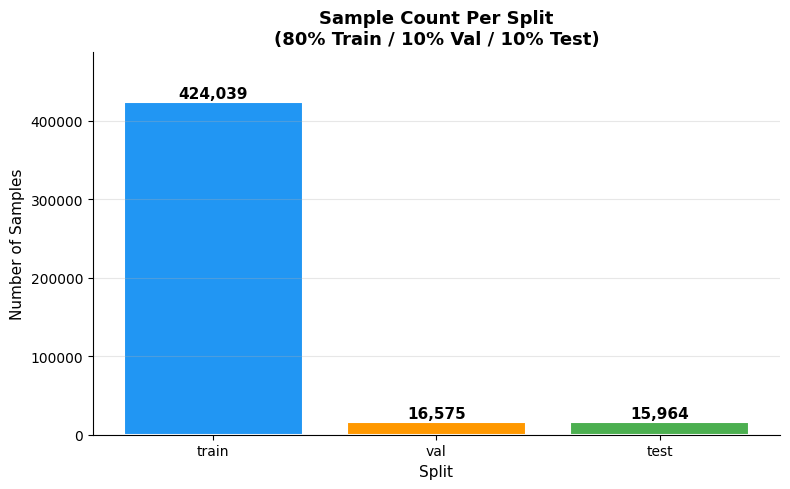

✅ Figure 1 saved
   Train: 424,039 (92.9%)
   Val:   16,575   (3.6%)
   Test:  15,964  (3.5%)


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))

split_counts = df['split'].value_counts().reindex(['train', 'val', 'test'])
colors = ['#2196F3', '#FF9800', '#4CAF50']

bars = ax.bar(split_counts.index, split_counts.values,
              color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, split_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Sample Count Per Split\n(80% Train / 10% Val / 10% Test)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Split', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_ylim(0, split_counts.max() * 1.15)
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('figure1_sample_count_per_split.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Figure 1 saved")
print(f"   Train: {split_counts['train']:,} ({split_counts['train']/split_counts.sum()*100:.1f}%)")
print(f"   Val:   {split_counts['val']:,}   ({split_counts['val']/split_counts.sum()*100:.1f}%)")
print(f"   Test:  {split_counts['test']:,}  ({split_counts['test']/split_counts.sum()*100:.1f}%)")

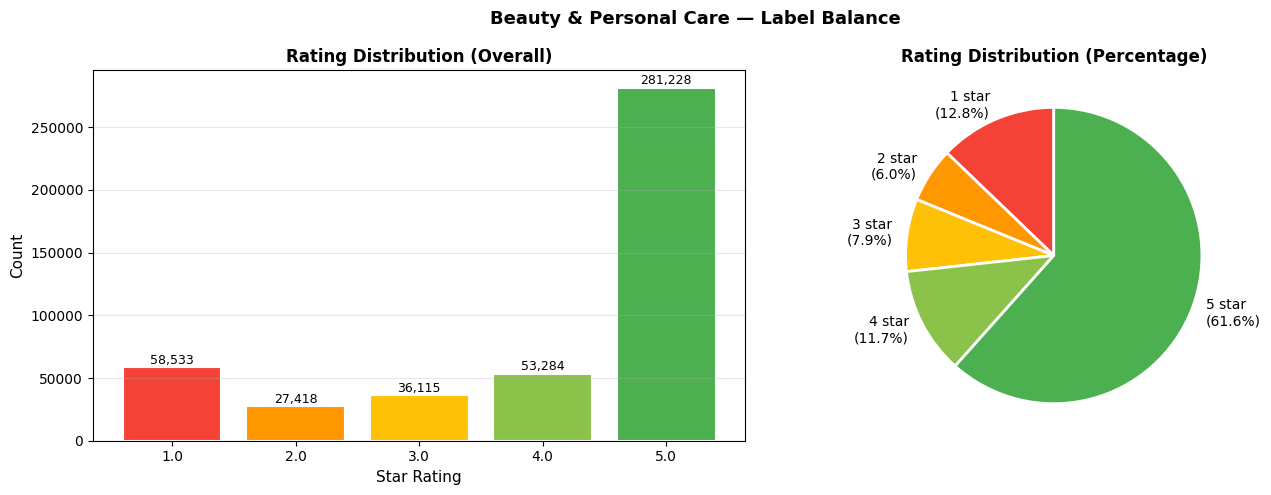

✅ Figure 2 saved
   Most common rating: 5.0 star (61.6%)
   Class imbalance ratio (5-star vs 1-star): 4.8x


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = df['rating'].value_counts().sort_index()
colors = ['#f44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']

axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
            color=colors, edgecolor='white', linewidth=1.5)
for i, (idx, val) in enumerate(rating_counts.items()):
    axes[0].text(i, val + 500, f'{val:,}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Rating Distribution (Overall)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Star Rating', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

rating_pct = rating_counts / rating_counts.sum() * 100
axes[1].pie(
    rating_pct.values,
    labels=[f'{int(r)} star\n({p:.1f}%)' for r, p in zip(rating_pct.index, rating_pct.values)],
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Rating Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.suptitle('Beauty & Personal Care — Label Balance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure2_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Figure 2 saved")
print(f"   Most common rating: {rating_counts.idxmax()} star ({rating_pct.max():.1f}%)")
print(f"   Class imbalance ratio (5-star vs 1-star): {rating_counts[5.0]/rating_counts[1.0]:.1f}x")

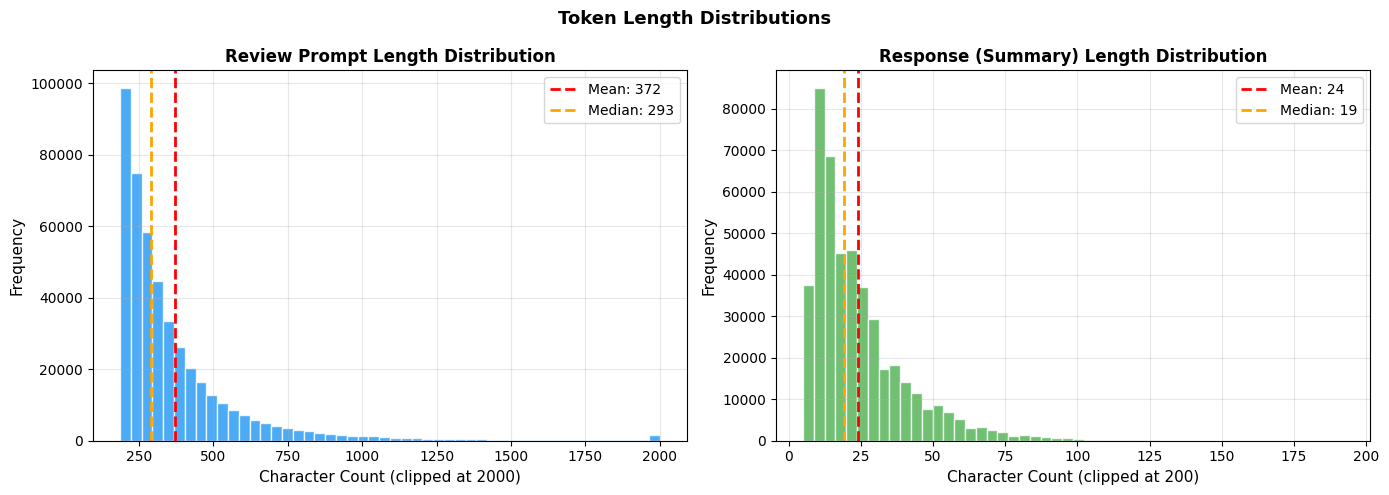

✅ Figure 3 saved
   Prompt   — Mean: 372 | Median: 293 | Max: 12001
   Response — Mean: 24 | Median: 19 | Max: 192

   → max_seq_length = 512 is sufficient for 95%+ of samples


In [46]:
# Use 'prompt' column — this is the full review text
df['prompt_len']   = df['prompt'].str.len()
df['response_len'] = df['response'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['prompt_len'].clip(upper=2000), bins=50,
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(df['prompt_len'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {df['prompt_len'].mean():.0f}")
axes[0].axvline(df['prompt_len'].median(), color='orange', linestyle='--',
                linewidth=2, label=f"Median: {df['prompt_len'].median():.0f}")
axes[0].set_title('Review Prompt Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character Count (clipped at 2000)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(df['response_len'].clip(upper=200), bins=50,
             color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].axvline(df['response_len'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {df['response_len'].mean():.0f}")
axes[1].axvline(df['response_len'].median(), color='orange', linestyle='--',
                linewidth=2, label=f"Median: {df['response_len'].median():.0f}")
axes[1].set_title('Response (Summary) Length Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Character Count (clipped at 200)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Token Length Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Figure 3 saved")
print(f"   Prompt   — Mean: {df['prompt_len'].mean():.0f} | Median: {df['prompt_len'].median():.0f} | Max: {df['prompt_len'].max():.0f}")
print(f"   Response — Mean: {df['response_len'].mean():.0f} | Median: {df['response_len'].median():.0f} | Max: {df['response_len'].max():.0f}")
print(f"\n   → max_seq_length = 512 is sufficient for 95%+ of samples")

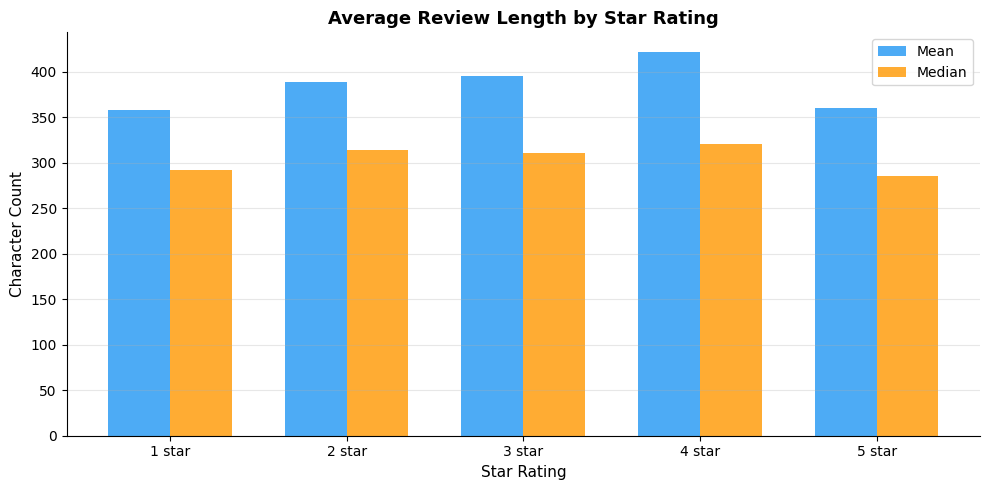

✅ Figure 4 saved
   1 star — Mean: 357 | Median: 292
   2 star — Mean: 389 | Median: 314
   3 star — Mean: 395 | Median: 311
   4 star — Mean: 422 | Median: 321
   5 star — Mean: 360 | Median: 285


In [47]:
fig, ax = plt.subplots(figsize=(10, 5))

rating_len = df.groupby('rating')['prompt_len'].agg(['mean', 'median']).reset_index()

x     = range(len(rating_len))
width = 0.35

ax.bar([i - width/2 for i in x], rating_len['mean'],
       width, label='Mean', color='#2196F3', alpha=0.8)
ax.bar([i + width/2 for i in x], rating_len['median'],
       width, label='Median', color='#FF9800', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels([f'{int(r)} star' for r in rating_len['rating']])
ax.set_title('Average Review Length by Star Rating', fontsize=13, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=11)
ax.set_ylabel('Character Count', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('figure4_length_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Figure 4 saved")
for _, row in rating_len.iterrows():
    print(f"   {int(row['rating'])} star — Mean: {row['mean']:.0f} | Median: {row['median']:.0f}")

In [48]:
figures = [
    'figure1_sample_count_per_split.png',
    'figure2_rating_distribution.png',
    'figure3_token_length_distribution.png',
    'figure4_length_by_rating.png'
]

for fig_file in figures:
    s3.upload_file(fig_file, BUCKET, f'processed/eda/{fig_file}')
    print(f"✅ Uploaded: {fig_file}")

print(f"\nAll figures at: s3://{BUCKET}/processed/eda/")

✅ Uploaded: figure1_sample_count_per_split.png
✅ Uploaded: figure2_rating_distribution.png
✅ Uploaded: figure3_token_length_distribution.png
✅ Uploaded: figure4_length_by_rating.png

All figures at: s3://25tvtm-cisc886-bucket-cloud-project/processed/eda/
